---
# Computergestützte Datenauswertung
**Institut für Experimentelle Teilchenphysik (ETP)** <br>
**Institut für Theorie der Kondensierten Materie (TKM)** <br>
Prof. Dr. Jan Kieseler (ETP), Dr. Joscha Ahäuser (ETP) <br>
Dr. Thorsten Chwalek (ETP), Dr. Andreas Poenicke (TKM) <br>
[ILIAS-Seite zum Kurs](https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&cmdNode=xs:mo&cmdClass=ilobjcoursegui&ref_id=2891557&item_ref_id=0) <br>
Sommersemester 2026 – Blatt 03 <br>
Abgabe: Montag, 18.05.2026 oder Dienstag, 19.05.2026 

---

Werbung 

![RocketScience2](RocketScience2.png)

Werbung Ende 

Die [erste Aufgabe](#Aufgabe1) bietet Ihnen die Gelegenheit, sich mit der <mark>Fortpflanzung von Unsicherheiten für einfache Kombinationen von Zufallszahlen</mark> auseinanderzusetzen.
Die [zweite Aufgabe](#Aufgabe2) bietet Ihnen die Gelegenheit, die <mark>Bedeutung von Korrelation und Kovarianzmatrix</mark> visuell zu verdeutlichen.



---
# Aufgabe 1: Fortpflanzung von Unsicherheiten <a id="Aufgabe1"></a>
---
In dieser Aufgabe folgen Sie dem Beispiel der Vorlesung, indem Sie die Fortpflanzung von Unsicherheiten für einen einfachen Fall selbst berechnen und testen können.
Im späteren Verlauf dieser Aufgabe werden Sie auch die Grenzen der Fortpflanzung von Unsicherheiten kennenlernen.
Betrachten Sie im Folgenden die Summe und den Quotienten von normalverteilten Zufallszahlen.

**Arbeitsanweisung:**<br>
Erzeugen Sie zwei Datensätze von je 5000 normalverteilten Zufallszahlen $x_i$ mit $(\mu_x,\,\sigma_x)=(1.5,\,0.5)$ und $y_i$ mit $(\mu_y,\,\sigma_y)=(0.6,\,0.15)$, wobei $\mu_x$ und $\mu_y$ die Lokalisierungsparameter und $\sigma_x$ und $\sigma_y$ die Skalierungsparameter der beiden Normalverteilungen sind.
Bilden Sie die Summe von Paaren von Zufallszahlen, $v_i=x_i + y_i$, und stellen Sie die Summen $v_i$ als Histogramm grafisch dar.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Initialisierung des Zufallsgenerators
rng = np.random.default_rng(42)

In [12]:
# Funktion für die Normalverteilung
def Gaussian(x, mu=0., sigma=1.):
    return np.exp(-0.5*(x - mu)**2 / sigma**2) / np.sqrt(2*np.pi) / sigma

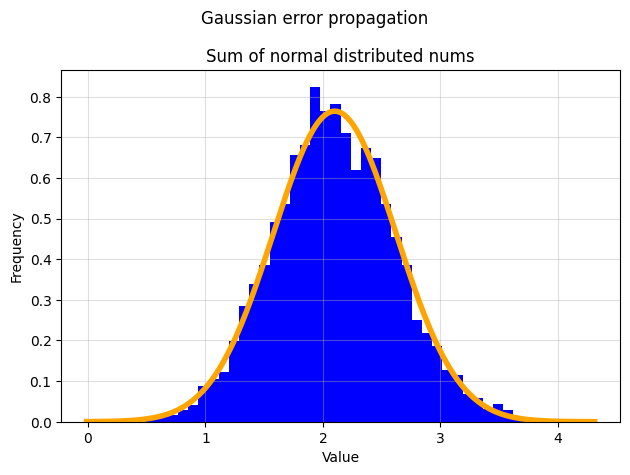

In [7]:
# -----Constants ----
#mean and standard deviation for gaussian normal distribution
mean_sig_x = (1.5, 0.5)
mean_sig_y = (0.6, 0.15)
size = 5e3
#bins should be 1% of different values in v
bins_mult = 1e-2

#normal distributed numbers
nums = list()

# ---- Create addends ----
for k in (mean_sig_x, mean_sig_y):
    m, sig = k
    nums.append(np.array(rng.normal(loc=m, scale=sig, size=int(size)), dtype=float))

x = nums[0]
y = nums[1]

#sum of normal distributed numbers
v = x + y

#compute the standard deviation of the linear function v

# ---- Craete comparison data ----
sig_x = mean_sig_x[-1]
sig_y = mean_sig_y[-1]

#gaussian error propagation for the case that f is linear dependent on experimental data and uncorrelated experimental data
"""
u = f(x_1, x_2) = x_1 \pm x_2.

du/dx1 = 1
du/dx2 = 1

(du/dx1)**2 * var_x1 + (du/dx2)**2 * var_x2
"""
#Vereinfachte version für summe, difference von Messgrößen
var_v = sig_x**2 + sig_y**2

# ---- Plot the data ----
fig, ax = plt.subplots(1, 1)

fig.suptitle('Gaussian error propagation')

# ---- Configure the axis ----
ax.set_title('Sum of normal distributed nums')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

ax.hist(v.tolist(),
        bins=int(len(v)*bins_mult),
        color='blue',
        label='gaussian sum',
        density=True)
ax.grid(alpha=0.4)

# ----plote comparison data ----
min_x, max_x = min(v) , max(v)
x_axis = np.linspace(min_x, max_x, int(1e3))
y_axis = Gaussian(x_axis,
                  mean_sig_x[0]+mean_sig_y[0],
                  np.sqrt(var_v))
ax.plot(x_axis, y_axis, color="orange", label='Gaussian curve', linewidth=4)

plt.tight_layout()
plt.show()


Berechnen Sie mithilfe des linearen Fehlerfortpflanzungsgesetzes die Standardabweichung $\sigma_v$ der $v_i$ und zeichnen Sie zum Vergleich eine Normalverteilung mit den Parametern $(\mu_v=\mu_x + \mu_y, \sigma_v)$ in das Histogramm ein.

**Hinweis:**<br>
Beachten Sie, dass für eine geeignete Darstellung entweder das Histogramm oder die Wahrscheinlichkeitsdichte der Normalverteilung richtig skaliert werden muss.

In [10]:
def unbiased_variance(values):
    """
    Args
    ----

    Params
    ------

    """
    return 1/(len(values)-1) * np.sum((values - np.mean(values))**2)



Bilden Sie nun das <mark>Verhältnis von jedem Paar von Zufallszahlen, $q_i=x_i/y_i$</mark>, und stellen Sie das Histogramm der Quotienten $q_i$ grafisch dar.
Berechnen Sie wieder mithilfe des <mark>linearen Fehlerfortpflanzungsgesetzes die Standardabweichung $\sigma_q$ der $q_i$ </mark> und zeichnen Sie zum Vergleich eine Normalverteilung mit $(\mu_q=\mu_x / \mu_y, \sigma_q)$ ein.
<mark>Vergleichen Sie den Mittelwert und die Standardabweichung dieser Normalverteilung mit dem Wert der Stichprobenstandardabweichung</mark>, die Sie direkt aus den Datensätzen erhalten.
Wird die Erwartung aus der Fortpflanzung der Unsicherheiten, dass eine Funktion zweier Normalverteilungen wieder eine Normalverteilung ergibt, durch die beobachtete Verteilung der Daten bestätigt? Falls Sie Abweichungen von einer Normalverteilung beobachten: wodurch könnten diese begründet sein?

**Hinweis:**<br>
Für eine bessere visuelle Darstellung des Histogramms und der Normalverteilung stellen Sie nur Werte für $q\in[-1, 10]$ dar.

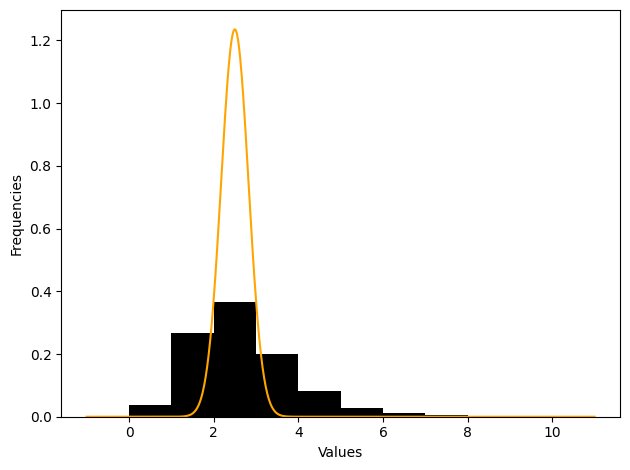

sig_u: 0.568257570707744
 unbiased sig_u: 1.297785804784123
 sig_u/sig_u_unbiased : 0.43786699516432864


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# -----Constants ----
#mean and standard deviation for gaussian normal distribution
mean_sig_x = (1.5, 0.5)
mean_sig_y = (0.6, 0.15)
size = 5e3
#bins should be 1% of different values in v
bins_mult = 1e-2

rand_nums = list()

#create normal distributed numbers
rng = np.random.default_rng()
for k in (mean_sig_x, mean_sig_y):
    rand_nums.append(rng.normal(loc=k[0], scale=k[-1], size=int(size)))

# Berechnung des Quotienten der Zufallszahlen
# u(x, y) = x/y
x = rand_nums[0]
y = rand_nums[-1]
u = x / y

"""
!!! Gaußsche Fehlerfortpflanzung setzt Mittelwerte der Messgrößen ein.
u(x, y) = x/y

du/dx = 1/y_m
du/dy = -x_m/y_m²

var_u = var_x/y_m - var_y*x_m/y_m²
"""

#Berechnung der variance aus der Fehlerfortpflanzung
var_u= (mean_sig_x[-1]**2/mean_sig_y[0]
        - mean_sig_y[-1]**2*mean_sig_x[0]/mean_sig_y[0]**2)

# Darstellung des Histogramms und der Normalverteilung
fig, ax = plt.subplots(1, 1)
ax.hist(u.tolist(), bins=range(-1, 11), color='black', density=True)
ax.set_xlabel('Values')
ax.set_ylabel('Frequencies')

x_axis = np.linspace(-1, 11, int(1e3))
y_axis = Gaussian(x_axis, mean_sig_x[0]/mean_sig_y[0], var_u)

ax.plot(x_axis, y_axis, 'orange')

plt.tight_layout()
plt.show()

#Vergleich der Stichprobenstandardabweichung mit dem berechneten ert der standardabweichung aus der fehlerfortpflanzung

sig_u_unbiased = np.sqrt(unbiased_variance(u))

print(f"sig_u: {np.sqrt(var_u)}\n unbiased sig_u: {sig_u_unbiased}\n sig_u/sig_u_unbiased : {np.sqrt(var_u)/sig_u_unbiased}")

---
# Aufgabe 2: Korrelierte Zufallszahlen und deren Unsicherheiten <a id="Aufgabe2"></a>
---
In dieser Aufgabe sollen Sie sich mit <mark>korrelierten Zufallszahlen und dem Unterschied beschäftigen, den die Berücksichtigung von Korrelationen bei der Fortpflanzung von Unsicherheiten im Vergleich zum "naiven" Ansatz ohne Korrelationen</mark> erzeugt.
Dazu gehen Sie zurück zu dem Beispiel der Summe zweier Zufallszahlen.
Für die Bearbeitung dieser Aufgabe müssen Sie allerdings einen neuen Satz von korrelierten Zufallszahlen $w$ und $z$ erzeugen.

**Arbeitsanweisung:**<br>
Erzeugen Sie zwei Datensätze von je 5000 normalverteilten Zufallszahlen <mark>$w$ mit $(\mu_w,\,\sigma_w)=(1.5,\,0.5)$ und $z$ mit $(\mu_z,\,\sigma_z)=(0.6,\,0.15)$ mit einem Korrelationskoeffizienten von $\rho_{wz}=0.9$.</mark>
Hierzu können Sie die Methode [`numpy.random.Generator.multivariate_normal(mean, cov)`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multivariate_normal.html) verwenden.
Übergeben Sie als `mean` ein Array aus den beiden Mittelwerten und als `cov` ein Array der Kovarianzmatrix.

**Hinweis:**<br>
Konstruieren Sie die Kovarianzmatrix $\mathbf{V}$ aus den Unsicherheiten $\sigma_{w}$ und $\sigma_{z}$ der einzelnen Sätze an Zufallszahlen und $\sigma_{wz}=\rho_{wz}\sigma_{w}\sigma_{z}$.

\begin{equation}
\mathbf{V} = 
\begin{pmatrix}
\sigma_w^2 & \rho_{wz}\sigma_{w}\sigma_{z} \\
\rho_{wz}\sigma_{w}\sigma_{z} & \sigma_z^2 \\
\end{pmatrix}
\end{equation}

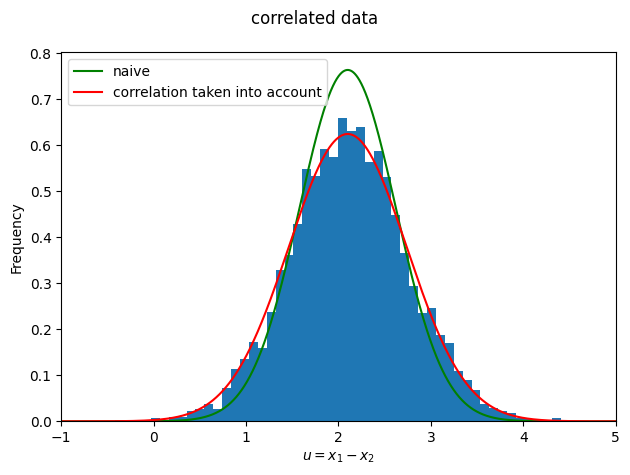

In [17]:
"""illustrate distribution of sums of two random numbers influenced by correlations"""
import numpy as np
import matplotlib.pyplot as plt

# ---- Constants ----
N = 5000

#mean and standard deviations for normal distributed ranom numbers
w_m, w_std = 1.5, 0.5
z_m, z_std = 0.6, 0.15

#correlation coefficient
rho_wz = 0.9

#expected value vector
mean_wz = np.array([w_m, z_m], dtype=float)

#2x2 covariance matrice
cor_wz = np.array([[w_std**2, rho_wz*w_std*z_std],
                   [rho_wz*w_std*z_std, z_std**2]],
                  dtype=float)

# Erzeugung der Verteilung der Zufallszahlen
rng = np.random.default_rng()
w, z = rng.multivariate_normal( mean_wz, cor_wz, size=N ).T

u = w + z

#compute the standard deviation of u: u_std

#not taking into account that data is correlated: using the simplification for a linear function u_std = w_std+z_std
u_sig_naive = w_std**2+z_std**2

"""
Connection between correlation coefficient and Cov(z, w)

rho_zw = Cov(z, w)/(std_z, std_w)
"""
#taking into account that data is correlated
u_sig = u_sig_naive + 2*rho_wz * z_std * w_std

fig, ax = plt.subplots(1, 1)
fig.suptitle('correlated data')

#plot data of linear function u
ax.hist(u.tolist(), bins=int(len(u)*1e-2), density=True)
ax.set_xlim(xmin=-1, xmax=5)

ax.set_xlabel( "$u = x_1 - x_2$" )
ax.set_ylabel( "Frequency" )

#plot comparison gaussians
x_axis = np.linspace(start=-1, stop=5, num=N)
y_axis_naive = Gaussian(x_axis, w_m + z_m, np.sqrt(u_sig_naive))
y_axis = Gaussian(x_axis, w_m + z_m, np.sqrt(u_sig))

ax.plot(x_axis.tolist(), y_axis_naive.tolist(), color='green', label='naive')
ax.plot(x_axis.tolist(), y_axis.tolist(), color='red', label='correlation taken into account')

ax.legend()
plt.tight_layout()
plt.show()




Bilden Sie die Summen aller Paare von Zufallszahlen, $u_i=w_i + z_i$, und stellen Sie die Summen $u_i$ als Histogramm grafisch dar.
Zeichnen Sie zum Vergleich die PDFs zweier Normalverteilung mit $(\mu_v=\mu_w + \mu_z, \sigma_u)$ in das Histogramm ein.
Berechnen Sie $\sigma_u$ mithilfe des linearen Fehlerfortpflanzungsgesetzes einmal ohne und einmal mit Berücksichtigung der Korrelation.

In [ ]:
# Berechnung der Summe der Zufallszahlen


# Berechnung der statistischen Größen aus der Fehlerfortpflanzung


# Darstellung der Ergebnisse
